In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import torch.optim as optim
import random

1, Parameters

1.1, Neural network for 6 parameters

In [2]:
# Set random seeds for reproducibility
seed = 0
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

class ParamNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.fc1 = nn.Linear(1, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, 6)  

        self.param_ref = nn.Parameter(torch.tensor([0.50, 0.03, 0.8, 2.0e6, 2.5*(24*3600), 0.30]), requires_grad=False)
        self.param_sd  = nn.Parameter(torch.tensor([0.15, 0.02, 0.4, 1.8e6, 2.0*(24*3600), 0.20]), requires_grad=False)
    
    def forward(self, x):
        # x: shape [W,1]
        h = F.relu(self.fc1(x))
        h = F.relu(self.fc2(h))
        b = self.fc3(h)   # [W,6],  raw
        b = torch.tanh(b) # [-1,1]
        
        
        param_6 = self.param_ref + b*self.param_sd  # shape [W,6]
        return param_6  # [W,6]

1.2, Total 9 parameters

In [3]:
def build_param_11(param_6,W,H):
    
    # constant values
    Cv_w = 4.19e6             # unit:Jm-3K-1
    Cv_i = 2.13e6             # unit:Jm-3K-1
    K_w  = 0.56*(24*3600)     # unit:Wm-1K-1
    K_i  = 2.26*(24*3600)     # unit:Wm-1K-1
    K_snow = 0.20*(24*3600)  # unit:Wm-1K-1

    param_11_list = [
        param_6[:,0],  # theta_sat
        param_6[:,1],  # theta_res
        param_6[:,2],  # tau
        param_6[:,3],  # Cv_s
        torch.full_like(param_6[:,0], Cv_w),
        torch.full_like(param_6[:,0], Cv_i),
        param_6[:,4],  # K_s
        torch.full_like(param_6[:,0], K_w),
        torch.full_like(param_6[:,0], K_i),
        param_6[:,5],  # depth of snow (m)
        torch.full_like(param_6[:,0], K_snow),
    ]

    param_11 = torch.stack(param_11_list, dim=-1)  # shape [W,11]

    # broadcast to [H,W,11]
    param_2d = param_11.unsqueeze(0).expand(H, -1, -1)
    return param_2d

2, Constitutive relationships

In [4]:
# ------------------- Cv & K --------------------
def C_veq_2d(T_2d, param_2d, L):
    
    theta_sat   = param_2d[...,0] #[H, W]
    theta_res   = param_2d[...,1]
    tau         = param_2d[...,2]
    Cv_s        = param_2d[...,3]
    Cv_w        = param_2d[...,4]
    Cv_i        = param_2d[...,5]

    a = torch.where(T_2d >= 0, theta_sat, theta_res+(theta_sat-theta_res)*torch.exp(T_2d/tau)) 
    b = theta_sat - a 

    base_Cv = (1-theta_sat)*Cv_s + a*Cv_w + b*Cv_i #[H, W]

    dwdT = torch.where(T_2d >= 0, torch.zeros_like(T_2d), (theta_sat-theta_res)/tau*torch.exp(T_2d/tau)) #[H, W]
    latent_term = L*dwdT #[H, W]

    Cv_eq = base_Cv + latent_term #[H, W]
    return Cv_eq #[H, W]

def K_eq_2d(T_2d, param_2d):
  
    theta_sat   = param_2d[...,0] #[H, W]
    theta_res   = param_2d[...,1]
    tau         = param_2d[...,2]
    K_s         = param_2d[...,6]
    K_w         = param_2d[...,7]
    K_i         = param_2d[...,8]

    a = torch.where(T_2d >= 0, theta_sat, theta_res+(theta_sat-theta_res)*torch.exp(T_2d/tau)) 
    b = theta_sat - a 

    logK = (1-theta_sat)*torch.log(K_s) + a*torch.log(K_w) + b*torch.log(K_i)
    return torch.exp(logK)

3， Upper boundary condition (Air temperature)

In [5]:
#Upper boundary condition
def get_air_temp(W,t,boundary_df):
    
    index = t // 20
    if index < len(boundary_df):
        temp = boundary_df.iloc[index]["T (2m)"] 
    else:
        temp = boundary_df.iloc[-1]["T (2m)"]
    return temp * torch.ones(W, dtype=torch.float32)

4, FDM solver

In [6]:
from datetime import datetime
def finite_difference_update_dm(u, dt, dx, dz, param_6, L, T_air, step, start_date):
    # 1) param_2d => [H,W,11]
    H, W = u.shape
    param_2d = build_param_11(param_6,W,H)  #shape [H，W，11]

    # 2) "day_offset" 
    
    step_t = torch.tensor(float(step), dtype=u.dtype, device=u.device)
    day_offset = step_t * dt  # shape=()
    day = float(day_offset)

    # 3) Snow thickness function
    if 6 <= start_date.month <= 10:
        oct_year = start_date.year
    else:
        oct_year = start_date.year - 1

    t_oct1 = (datetime(oct_year, 10, 1) - start_date).days
    t_dec1 = (datetime(oct_year, 12, 1) - start_date).days
    t_may1 = (datetime(oct_year+1, 5, 1) - start_date).days
    t_jun1 = (datetime(oct_year+1, 6, 1) - start_date).days

    # 4) maximum snow thickness
    max_snow = param_2d[0, :, 9]  # shape [W]

    # 5) current h_snow_time: shape [W]
    if day < t_oct1:
        h_snow_time = torch.zeros_like(max_snow)
    elif day < t_dec1:
        h_snow_time = max_snow * (day - t_oct1) / (t_dec1 - t_oct1)
    elif day < t_may1:
        h_snow_time = max_snow
    elif day < t_jun1:
        h_snow_time = max_snow * (1 - (day - t_may1) / (t_jun1 - t_may1))
    else:
        h_snow_time = torch.zeros_like(max_snow)

    # 6) replicate pad => [H+2, W+2]
    u_pad = F.pad(u.unsqueeze(0).unsqueeze(0), (1,1,1,1), mode='replicate').squeeze(0).squeeze(0)

    # 7) 取 T_c, T_r, T_l, T_u, T_d => shape [H,W]
    T_c = u_pad[1:-1, 1:-1]     
    T_r = u_pad[1:-1, 2:]       
    T_l = u_pad[1:-1, 0:-2]
    T_u = u_pad[0:-2, 1:-1]
    T_d = u_pad[2:, 1:-1]

    # 8) 计算 Cv_c, K_r, K_l, K_u_, K_d_ => [H,W]
    Cv_c = C_veq_2d(T_c, param_2d, L)
    K_r  = K_eq_2d((T_c + T_r)/2, param_2d)
    K_l  = K_eq_2d((T_c + T_l)/2, param_2d)
    K_u_ = K_eq_2d((T_c + T_u)/2, param_2d)
    K_d_ = K_eq_2d((T_c + T_d)/2, param_2d)

    # 9) 2 order FDM
    d2T_dx2 = (K_r*(T_r - T_c) - K_l*(T_c - T_l)) / (dx**2)
    d2T_dz2 = (K_d_*(T_d - T_c) - K_u_*(T_c - T_u)) / (dz**2)

    # 10) update
    T_new_2d = T_c + dt*(d2T_dx2 + d2T_dz2)/Cv_c

    # 11) upper boundary
    T_new_2d = T_new_2d.clone()  

    
    K_top = K_eq_2d((T_new_2d[0,:] + T_new_2d[1,:])/2, param_2d)[0,:]  # shape [W]
    # Robin equation
    # T(0) * [ alpha + K_top/dz ] = alpha*T_air + (K_top/dz)*T(1)
    numerator   = dz*param_2d[0,:,10]*T_air+h_snow_time*K_top*T_new_2d[1,:]
    denominator = dz*param_2d[0,:,10]+h_snow_time*K_top
    T_surface   = numerator / denominator

    T_new_2d_out = T_new_2d.clone()
    T_new_2d_out[0, :] = T_surface
    
    return T_new_2d_out

5, Obversed data

5.1, Read in data

In [7]:
def parse_exp_times(df_exp, dt, start_date):
    
    time_cols = df_exp.columns[2:]
    exp_times = []
    for col in time_cols:
        col_date = datetime.strptime(col, "%m/%d/%Y")
        day_offset = (col_date - start_date).days
        step_idx = int(round(day_offset/dt))
        exp_times.append(step_idx)
    return time_cols, exp_times

5.2, Index of the data

In [8]:
def build_experiment_index_no_loop(df_exp, time_cols, exp_times, dt, dz, H, W):
    
    time_idx_list = []
    depth_idx_list = []
    x_idx_list = []
    obs_temp_list = []

    for i, col in enumerate(time_cols):
        step_idx = exp_times[i]  # PDE time step
        if step_idx<0:
            continue
        colIndex = df_exp.columns.get_loc(col)
        obs_vals = df_exp.iloc[:, colIndex].values  # shape [N]
        z_vals   = df_exp.iloc[:, 0].values
        x_vals   = df_exp.iloc[:, 1].values

        for n in range(len(obs_vals)):
            val = obs_vals[n]
            if pd.isna(val):
                continue
            z_val = z_vals[n]
            x_val = x_vals[n]
            d_idx = int(round(z_val/dz))
            x_i   = int(round(x_val))
            if step_idx>=0 and d_idx>=0 and x_i>=0 and step_idx<9999999:

                time_idx_list.append(step_idx)
                depth_idx_list.append(d_idx)
                x_idx_list.append(x_i)
                obs_temp_list.append(val)

    # to PyTorch
    time_idx_t = torch.tensor(time_idx_list, dtype=torch.long)
    depth_idx_t= torch.tensor(depth_idx_list, dtype=torch.long)
    x_idx_t    = torch.tensor(x_idx_list, dtype=torch.long)
    obs_temp_t = torch.tensor(obs_temp_list, dtype=torch.float32)
    return time_idx_t, depth_idx_t, x_idx_t, obs_temp_t


6, Loss function

In [9]:
def compute_loss_no_loop(u_tensor, time_idx, depth_idx, x_idx, obs_temp, device, H, W):
    
    T_ = u_tensor.shape[0]
    valid_mask = (time_idx>=0) & (time_idx<T_) & (depth_idx>=0) & (depth_idx<H) & (x_idx>=0) & (x_idx<W)
    
    time_idx = time_idx[valid_mask].to(device)
    depth_idx= depth_idx[valid_mask].to(device)
    x_idx    = x_idx[valid_mask].to(device)
    obs_temp = obs_temp[valid_mask].to(device)

    if len(time_idx)==0:
        return torch.zeros((), device=device, requires_grad=True)
    
    temp_sim = u_tensor[time_idx, depth_idx, x_idx]  # GPU上
    diff = temp_sim - obs_temp
    loss = (diff*diff).mean()
    return loss


7, DM procedure

In [ ]:
# ------------------------------- Main procedure -----------------------------------
if __name__ == "__main__":
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  print("Using device:", device)
  
  # grid
  H, W = 71, 101
  dz, dx = 0.15, 1  # unit: m
  dt = 0.05        # unit: day
  num_steps = 91*20
  start_date = datetime(2024,1,31)

  param_net = ParamNet(hidden_dim=32).to(device)

  # initinial condition
  # pde_result = np.load("Pre_files/u_tensor_first_train.npy")
  init_np = np.load("Pre_files/u_tensor_first_train_last_frame.npy")
  #pde_result[-1]  # shape [H, W], numpy array
  # print(init_np.shape)
  u0 = torch.tensor(init_np, dtype=torch.float32).to(device)
  print("u0 shape: ", u0.shape)

  # upper boundary condition
  air_temp_df = pd.read_excel("Pre_files/Upper boundary condition_1_31_2024_4_30_2024.xlsx")
  air_temp_df["Date"] = pd.to_datetime(air_temp_df["Date"], format="%m/%d/%Y")
  #print(boundary_df.head())
  #print(boundary_df.shape)

  # observed data
  df_exp = pd.read_excel("Pre_files/Observed_data_2_1_2024_4_30_2024.xlsx", header=0) 
  # print(df_exp.head())
  time_cols, exp_times = parse_exp_times(df_exp, dt, start_date)
  time_idx_t, depth_idx_t, x_idx_t, obs_temp_t = build_experiment_index_no_loop(df_exp, time_cols, exp_times, dt, dz, H, W)

  # NN input
  avg_temp_df = pd.read_excel("Pre_files/Attribute.xlsx", header=0)  
  x_coords = avg_temp_df.iloc[:, 0].values.astype(float)  
  avg_temp = avg_temp_df.iloc[:, 1].values.astype(float)  

  # Min-Max normalize [0,1]
  avg_temp_min, avg_temp_max = avg_temp.min(), avg_temp.max()
  avg_temp_norm = (avg_temp - avg_temp_min) / (avg_temp_max - avg_temp_min)

  # to tensor
  avg_temp_input = torch.tensor(avg_temp_norm, dtype=torch.float32).view(-1, 1).to(device)
  print("avg_temp_input shape: ", avg_temp_input.shape)  # [W, 1]

  # op
  optimizer = optim.Adam(filter(lambda p: p.requires_grad, param_net.parameters()), lr=1e-3)
  epochs = 1000
  loss_history = []

  for epoch in range(epochs):
      # change lr 
      if epoch < 400:
          lr = 1e-3
      else:
          lr = 1e-4    
     
      for param_group in optimizer.param_groups:
          param_group['lr'] = lr

      optimizer.zero_grad()

      # forward PDE
      u_seq = []
      u_seq.append(u0.clone())
      u = u0.clone()
      #col_x = torch.linspace(0,1,W).view(-1,1).to(device)

      for step in range(num_steps):
          param_6 = param_net(avg_temp_input)  # [W,5]
          air_temp = get_air_temp(W, step, air_temp_df).to(device)
          u = finite_difference_update_dm(u, dt, dx, dz, param_6, L = 3.34e8, T_air = air_temp, step = step, start_date = start_date)
          u_seq.append(u.clone())
      u_tensor = torch.stack(u_seq, dim=0)  # [T,H,W]

      # compute loss without for loop
      loss = compute_loss_no_loop(u_tensor, time_idx_t, depth_idx_t, x_idx_t, obs_temp_t, device, H, W)
      loss.backward()
      optimizer.step()
      loss_history.append(loss.item())
      print(f"Epoch {epoch+1}, LR={lr}, Loss={loss.item():.4f}")

      if (epoch +1) % 100 == 0:
        # (A) NN output
        with torch.no_grad():
            param_6_final = param_net(avg_temp_input).cpu().numpy()
            filename = f"param_6_epoch_{epoch+1}.csv"
            np.savetxt(filename, param_6_final, delimiter=",",
                      header="theta_sat,theta_res,tau,Cv_s,K_s,snow depth", comments="")
            print(f"Saved param_6 to {filename} at epoch {epoch+1}")

            # (B) Soil temp field
            temp_filename = f"u_tensor_epoch_{epoch+1}.npy"
            np.save(temp_filename, u_tensor.detach().cpu().numpy())
            print(f"Saved temperature field to {temp_filename} at epoch {epoch+1}")


torch.save(param_net.state_dict(), "UM1_model.pth")
print("Fine tuned model for date batch 2 saved to UM1_model.pth")


plt.figure(figsize=(8,5))
plt.plot(loss_history, label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

Using device: cuda
u0 shape:  torch.Size([71, 101])
avg_temp_input shape:  torch.Size([101, 1])
Epoch 1, LR=0.001, Loss=6.5709


Loss plot

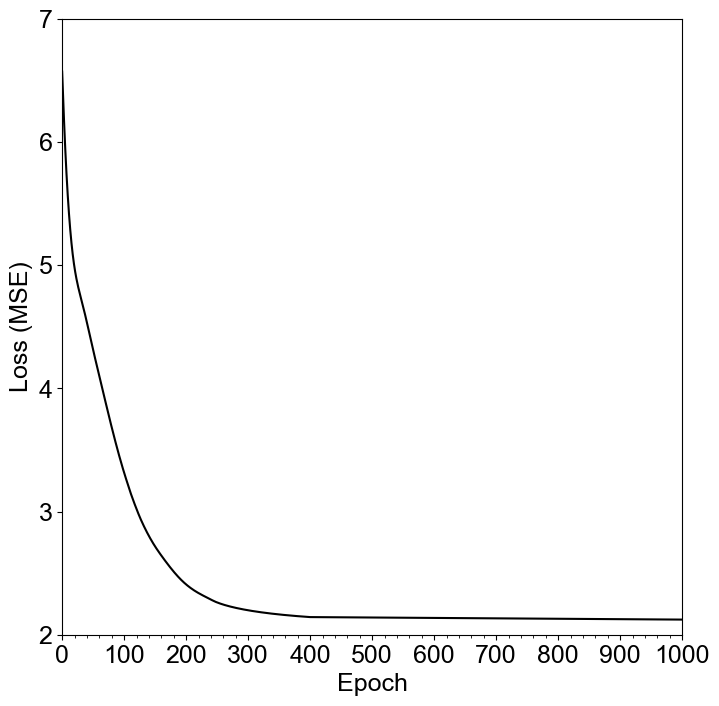

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import NullFormatter

# loss curve
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 18

plt.figure(figsize=(8,8))
plt.plot(loss_history, label="Training Loss", color='black')
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
#plt.legend()
plt.xlim(0, 1000)

ax = plt.gca()
ax.set_xticks(np.arange(0, 1001, 100))
ax.set_yticks(np.arange(2, 8, 1))

ax.set_xticks(np.arange(0, 1001, 20), minor=True)
ax.set_yticks(np.arange(2, 8, 1), minor=True)

ax.xaxis.set_minor_formatter(NullFormatter())
ax.yaxis.set_minor_formatter(NullFormatter())

plt.ylim(2, 7)
plt.show()

loss_df = pd.DataFrame(loss_history, columns=["Loss (MSE)"])
loss_df.to_excel("loss_history_UM1.xlsx", index=False)

8, load data

In [ ]:
with torch.no_grad():
    col_x = torch.linspace(0, 1, W).view(-1, 1).to(device)
    param_6_final = param_net(col_x)  # [W,6]
    np.savetxt("param_6_matrix_second_train.csv", param_6_final.cpu().numpy(), delimiter=",",
               header="theta_sat,theta_res,tau,Cv_s,K_s,snow depth", comments="")
    print("Saved parameter matrix to param_6_matrix_second_train.csv")

    np.save("u_tensor_second_train", u_tensor.detach().cpu().numpy())
    print(f"Saved temperature field to u_tensor_second_train.csv")

Saved parameter matrix to param_6_matrix_second_train.csv
Saved temperature field to u_tensor_second_train.csv
